# Credit Card Clustering

https://amanxai.com/2022/10/03/credit-card-clustering-with-machine-learning/

dataset:https://www.kaggle.com/datasets/arjunbhasin2013/ccdata

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/arjunbhasin2013/ccdata/CC GENERAL.csv


In [2]:
import pandas as pd
pd.set_option("display.max_columns", 100)
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from yellowbrick.cluster import KElbowVisualizer

In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/arjunbhasin2013/ccdata/CC GENERAL.csv",
    encoding="latin1"
)

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [5]:
# I will drop the rows with null values and move further:

data = df.dropna()


In [7]:
data.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

There are three features in the dataset which are very valuable for the task of credit card segmentation:

- BALANCE: The balance left in the accounts of credit card customers.
- PURCHASES: Amount of purchases made from the accounts of credit card customers.
- CREDIT_LIMIT: The limit of the credit card.

These three features are enough to group credit card holders as they tell us about the buying history, bank balance, and credit limit of the credit card holders

In [8]:
data=data[["BALANCE", "PURCHASES", "CREDIT_LIMIT"]]

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x = scaler.fit_transform(data)

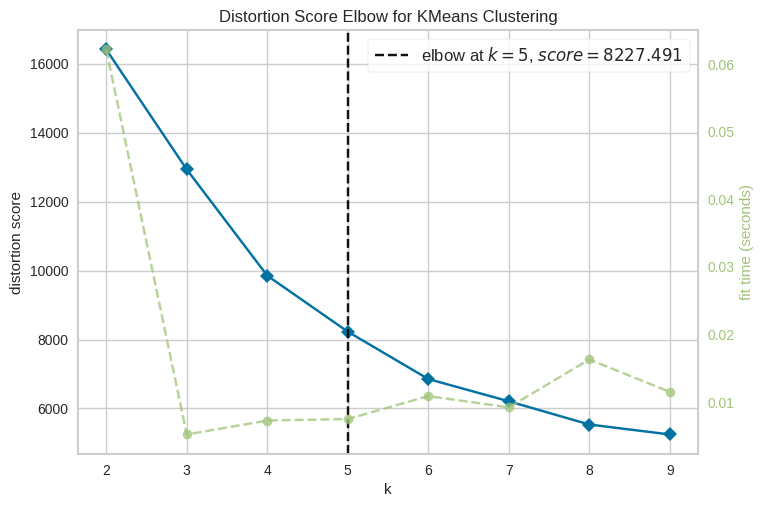

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [10]:
vis=KElbowVisualizer(KMeans(), k=(2,10)) #elbow u gösteren grafik
vis.fit(x)
vis.show()

In [11]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(x)

data["cluster"] = clusters

In [14]:
data.sample(10)

,BALANCE,PURCHASES,CREDIT_LIMIT,cluster
7827,342.742855,3673.32,4500.0,0
3077,1293.044047,0.00,1500.0,1
1134,2136.082193,0.00,6500.0,0
8086,957.289879,66.66,3000.0,1
4524,4251.411617,0.00,5000.0,0
8389,361.670150,561.68,1500.0,1
8618,272.310015,575.30,1500.0,1
490,4263.008734,3522.57,6000.0,3
3273,5905.955278,1642.94,12200.0,2
8624,1012.089680,312.48,1000.0,1


<Axes: xlabel='cluster', ylabel='count'>

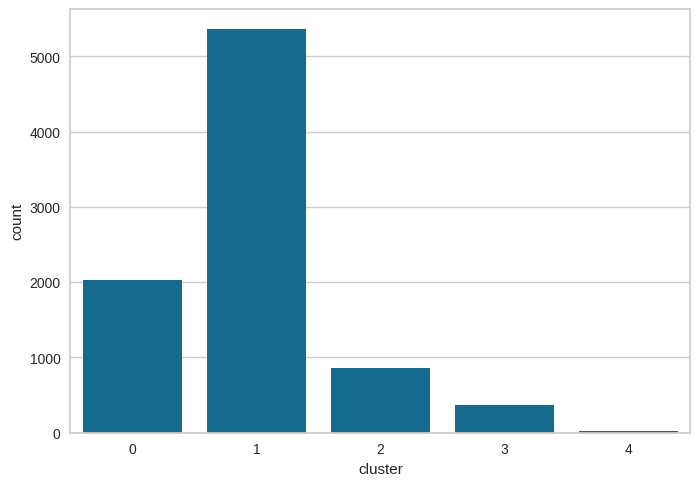

In [15]:
sns.countplot(x=data["cluster"])


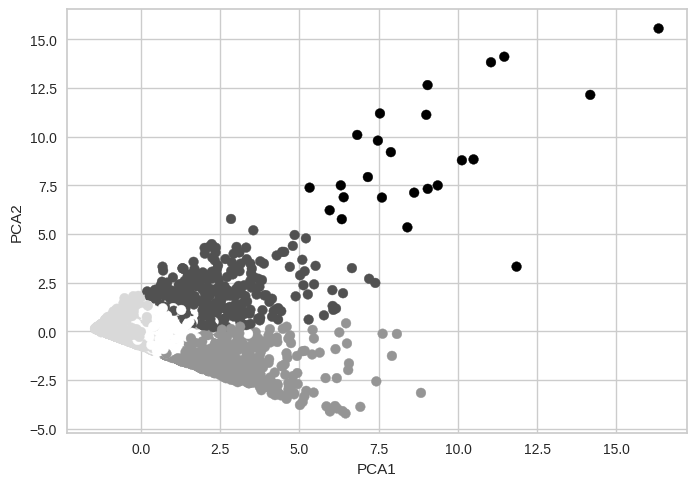

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

plt.scatter(x_pca[:,0], x_pca[:,1], c=clusters)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

In [18]:
cols=["BALANCE", "PURCHASES", "CREDIT_LIMIT"]

data[cols + ["cluster"]].groupby("cluster").mean()

,BALANCE,PURCHASES,CREDIT_LIMIT
cluster,,,
0,1404.441145,1041.321767,7477.806695
1,823.736129,527.094343,2240.348492
2,6474.295959,950.476920,9704.162231
3,2435.251703,6538.688449,8608.556150
4,5390.389571,27690.865833,16333.333333


Cluster 0 – Moderate Users with High Credit Access
Medium balance and purchases
Relatively high credit limit

These customers use their cards regularly but stay within reasonable limits.

Cluster 1 – Low Activity / Low Credit Users
Low balance, low purchases, low credit limit

This segment represents low-engagement customers with limited financial activity.

Cluster 2 – High Balance, Low Spending Users
Very high balance
Moderate purchases
High credit limit

These users tend to carry debt rather than actively spending.

Cluster 3 – High Spenders
Moderate balance
Very high purchases
High credit limit

This group includes active spenders who frequently use their credit cards.

Cluster 4 – Premium / Heavy Users
Very high purchases (extreme)
Very high credit limit
High balance

These are premium customers with strong purchasing power and heavy usage behavior.



The clustering results reveal distinct customer segments based on balance, spending behavior, and credit limits. These segments range from low-activity users to high-value premium customers, providing valuable insights for targeted marketing strategies and risk management.

In [19]:
import pickle

features = ["BALANCE", "PURCHASES", "CREDIT_LIMIT"]

artifacts = {
    "scaler": scaler,
    "kmeans": kmeans,
    "features": features
}

with open("credit_card_cluster.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print("Saved: credit_card_cluster.pkl")

Saved: credit_card_cluster.pkl
